In [1]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
image_dir = 'images'
ann_dir = 'ann'
hog_size = (64, 128)

Parsing XMLs and crop positives

In [5]:
def parse_ann(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.find('filename').text
    boxes = []
    for obj in root.findall('object'):
        bb = obj.find('bndbox')
        box = (
            int(bb.find('xmin').text),
            int(bb.find('ymin').text),
            int(bb.find('xmax').text),
            int(bb.find('ymax').text)
        )
        boxes.append(box)
    return filename, boxes

positive_features = []

for xml_file in os.listdir(ann_dir):
    if not xml_file.endswith('.xml'):
        continue
    xml_path = os.path.join(ann_dir, xml_file)
    filename, boxes = parse_ann(xml_path)
    image_path = os.path.join(image_dir, filename)
    img = cv2.imread(image_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    for (xmin, ymin, xmax, ymax) in boxes:
        crop = img[ymin:ymax, xmin:xmax]
        crop = cv2.resize(crop, hog_size)
        positive_features.append(crop)
print(f"Positives: {len(positive_features)}")

Positives: 1837


In [6]:
import random

def boxes_overlap(box, x, y, w, h):
    xmin, ymin, xmax, ymax = box
    return not (x + w < xmin or x > xmax or y + h < ymin or y > ymax)

negative_features = []
target_negatives = len(positive_features) * 2

for xml_file in os.listdir(ann_dir):
    if not xml_file.endswith(".xml"):
        continue
    xml_path = os.path.join(ann_dir, xml_file)
    filename, boxes = parse_ann(xml_path)
    img_path = os.path.join(image_dir, filename)
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h_img, w_img = img.shape
    attempts = 0
    while attempts < 20:
        x = random.randint(0, max(0, w_img - hog_size[0]))
        y = random.randint(0, max(0, h_img - hog_size[1]))
        overlap = any(boxes_overlap(b, x, y, hog_size[0], hog_size[1]) for b in boxes)
        if not overlap:
            crop = img[y:y+hog_size[1], x:x+hog_size[0]]
            if crop.shape == (hog_size[1], hog_size[0]):
                negative_features.append(crop)
        attempts += 1

negative_features = negative_features[:target_negatives]
print(f"Negatives: {len(negative_features)}")

Negatives: 3674


Extracting HOG features

In [7]:
def get_hog(image):
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    )
    return features

X, y = [], []

for img in positive_features:
    X.append(get_hog(img))
    y.append(1)

for img in negative_features:
    X.append(get_hog(img))
    y.append(0)

X = np.array(X)
y = np.array(y)

print(f"Feature vector shape: {X.shape}")

Feature vector shape: (5511, 3780)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True)
svm.fit(X_train, y_train)

print("Training done.")

Training done.


              precision    recall  f1-score   support

  background       0.97      0.99      0.98      1103
      person       0.97      0.95      0.96       551

    accuracy                           0.97      1654
   macro avg       0.97      0.97      0.97      1654
weighted avg       0.97      0.97      0.97      1654



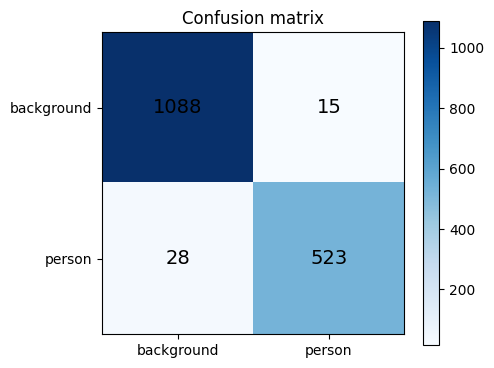

In [9]:
y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["background", "person"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1], ["background", "person"])
plt.yticks([0, 1], ["background", "person"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
plt.title("Confusion matrix")
plt.tight_layout()

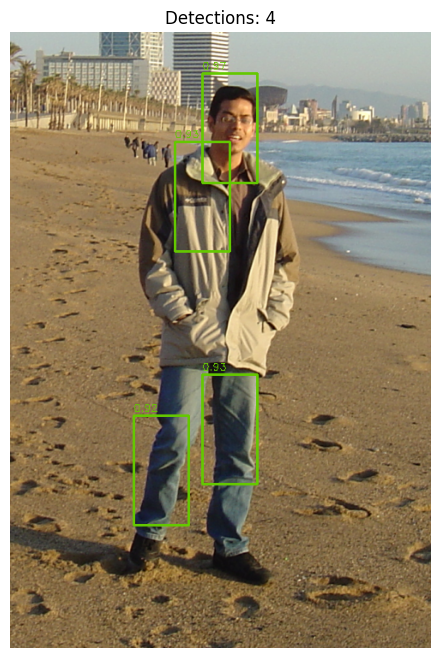

In [26]:
def sliding_window(image, step=16, win_size=(64, 128)):
    h, w = image.shape[:2]
    for y in range(0, h - win_size[1], step):
        for x in range(0, w - win_size[0], step):
            yield x, y, image[y:y+win_size[1], x:x+win_size[0]]

def detect_persons(img_path, threshold=0.85):
    img_color = cv2.imread(img_path)
    img_gray  = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    detections = []
    for (x, y, window) in sliding_window(img_gray, step=16):
        if window.shape != (128, 64):
            continue
        feat = get_hog(window).reshape(1, -1)
        prob = svm.predict_proba(feat)[0][1]
        if prob > threshold:
            detections.append((x, y, prob))

    result = img_color.copy()
    for (x, y, prob) in detections:
        cv2.rectangle(result, (x, y), (x+64, y+128), (0, 200, 100), 2)
        cv2.putText(result, f"{prob:.2f}", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 200, 100), 1)

    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(result_rgb)
    plt.axis("off")
    plt.title(f"Detections: {len(detections)}")
    plt.show()

detect_persons("images/crop_000001.png", threshold=0.85)